# EDA — Predicția Traiectoriei Baloanelor Meteorologice
Acest notebook explorează datele colectate de pe SondeHub și University of Wyoming,
pregătind terenul pentru antrenarea modelelor ML.


## 1. Import librării și încărcare date

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style="whitegrid")

print("Librarii incarcate cu succes!")


Librarii incarcate cu succes!


In [6]:
# Incarca datele SondeHub
df_sh = pd.read_csv(r"D:\User\Documents\GitHub\ML---proiect\Date\sondehub_europe_all.csv")
df_sh['datetime'] = pd.to_datetime(df_sh['datetime'], utc=True, errors='coerce')

print(f"SondeHub: {len(df_sh):,} randuri, {df_sh['serial'].nunique():,} lansari unice")
print(f"Perioada: {df_sh['datetime'].min()} -> {df_sh['datetime'].max()}")
df_sh.head()


SondeHub: 183,959 randuri, 67,842 lansari unice
Perioada: 2018-12-28 23:33:31.389866+00:00 -> 2026-04-28 02:48:39+00:00


,serial,datetime,lat,lon,alt,vel_v,vel_h,heading,temp,humidity,pressure,manufacturer,type,frame,sats,batt,frequency,launch_site
0,-2642263,2022-01-04 15:13:58+00:00,49.65673,15.18898,11106.05957,-23.56,52.28,84.84,-60.7,NaN,NaN,Graw,DFM,1325344438,10.0,4.78,401.510,NaN
1,-2940182,2022-10-14 06:44:20+00:00,51.40304,15.09214,9280.32031,2.56,16.44,126.69,-47.7,NaN,NaN,Graw,DFM,1349765060,9.0,3.92,403.300,NaN
2,-2940182,2022-10-14 06:44:36+00:00,51.40153,15.09507,9321.65039,2.66,16.53,131.97,-47.8,NaN,NaN,Graw,DFM,1349765076,9.0,4.86,403.300,NaN
3,-6AA43723,2022-07-12 12:41:48+00:00,44.92305,31.37911,44444.00000,NaN,NaN,NaN,25.6,NaN,NaN,Meteo-Radiy,MRZ-3MK,11,20.0,4.07,0.795,NaN
4,-6AA43723,2022-07-12 16:54:31+00:00,44.92305,31.37911,44444.00000,0.00,0.00,0.00,26.0,52.3,NaN,Meteo-Radiy,MRZ-3MK,32,20.0,3.87,0.796,NaN


In [7]:
# Incarca datele Wyoming
df_wy = pd.read_csv(r"D:\User\Documents\GitHub\ML---proiect\Date\wyoming_soundings.csv")
df_wy['datetime'] = pd.to_datetime(df_wy['time'], utc=True, errors='coerce')

print(f"Wyoming: {len(df_wy):,} randuri")
print(f"Statii unice: {df_wy['station_name'].nunique()}")
print(f"Perioada: {df_wy['datetime'].min()} -> {df_wy['datetime'].max()}")
df_wy.head()


Wyoming: 1,115,667 randuri
Statii unice: 7
Perioada: 2022-01-01 00:00:00+00:00 -> 2024-12-31 12:00:00+00:00


,pressure,height,temperature,dewpoint,direction,speed,u_wind,v_wind,station,station_number,time,latitude,longitude,elevation,pw,station_id,station_name,datetime
0,1008.0,91.0,4.6,3.7,295.0,4.0,3.625231,-1.690473,LRBS,15420,2022-01-01T00:00:00,44.5,26.13,91.0,20.84,15420,Bucuresti,2022-01-01 00:00:00+00:00
1,1000.0,161.0,4.4,4.1,275.0,8.0,7.969558,-0.697246,LRBS,15420,2022-01-01T00:00:00,44.5,26.13,91.0,20.84,15420,Bucuresti,2022-01-01 00:00:00+00:00
2,996.0,194.0,4.2,3.9,280.0,10.0,9.848078,-1.736482,LRBS,15420,2022-01-01T00:00:00,44.5,26.13,91.0,20.84,15420,Bucuresti,2022-01-01 00:00:00+00:00
3,984.0,294.0,7.1,4.7,300.0,16.0,13.856406,-8.000000,LRBS,15420,2022-01-01T00:00:00,44.5,26.13,91.0,20.84,15420,Bucuresti,2022-01-01 00:00:00+00:00
4,970.0,412.0,10.6,5.6,297.0,19.0,16.929124,-8.625819,LRBS,15420,2022-01-01T00:00:00,44.5,26.13,91.0,20.84,15420,Bucuresti,2022-01-01 00:00:00+00:00


## 2. Verificare valori lipsă

In [8]:
# Valori lipsa SondeHub
print("=== SONDEHUB — Valori lipsa ===")
lipsa_sh = df_sh.isnull().sum()
pct_sh   = (lipsa_sh / len(df_sh) * 100).round(1)
rezumat_sh = pd.DataFrame({'Lipsa': lipsa_sh, 'Procent %': pct_sh})
print(rezumat_sh[rezumat_sh['Lipsa'] > 0].sort_values('Procent %', ascending=False))


=== SONDEHUB — Valori lipsa ===
               Lipsa  Procent %
pressure      133288       72.5
launch_site    90159       49.0
humidity       69819       38.0
temp           63170       34.3
sats           43484       23.6
batt           33012       17.9
frequency       7505        4.1
vel_v            832        0.5
heading          462        0.3
vel_h            241        0.1
manufacturer     170        0.1
datetime           1        0.0


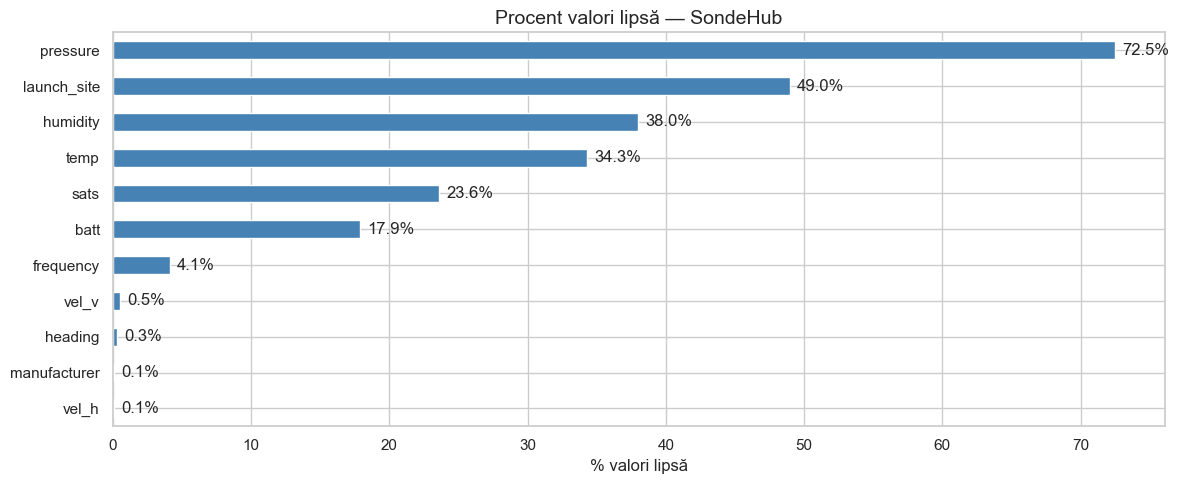

In [9]:
# Vizualizare valori lipsa SondeHub
fig, ax = plt.subplots(figsize=(12, 5))
pct_sh[pct_sh > 0].sort_values(ascending=True).plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Procent valori lipsă — SondeHub', fontsize=14)
ax.set_xlabel('% valori lipsă')
for i, v in enumerate(pct_sh[pct_sh > 0].sort_values()):
    ax.text(v + 0.5, i, f'{v}%', va='center')
plt.tight_layout()
plt.savefig('missing_values_sondehub.png', dpi=150)
plt.show()


In [10]:
# Valori lipsa Wyoming
print("=== WYOMING — Valori lipsa ===")
lipsa_wy = df_wy.isnull().sum()
pct_wy   = (lipsa_wy / len(df_wy) * 100).round(1)
rezumat_wy = pd.DataFrame({'Lipsa': lipsa_wy, 'Procent %': pct_wy})
print(rezumat_wy[rezumat_wy['Lipsa'] > 0].sort_values('Procent %', ascending=False))


=== WYOMING — Valori lipsa ===
              Lipsa  Procent %
station      858979       77.0
direction      7442        0.7
speed          7442        0.7
u_wind         7442        0.7
v_wind         7442        0.7
dewpoint       6509        0.6
height         4357        0.4
temperature    4357        0.4


## 3. Curățarea datelor SondeHub

In [11]:
print(f"Inainte: {len(df_sh):,} randuri")

df_sh = df_sh[df_sh['alt'] < 45000]
df_sh = df_sh[df_sh['alt'] >= 0]
df_sh = df_sh[df_sh['datetime'].notna()]
df_sh = df_sh.drop_duplicates(subset=['serial', 'datetime'])
df_sh = df_sh[df_sh['datetime'].dt.year >= 2022]

df_sh = df_sh.sort_values(['serial', 'datetime']).reset_index(drop=True)
df_sh['year']  = df_sh['datetime'].dt.year
df_sh['month'] = df_sh['datetime'].dt.month

print(f"Dupa curatare: {len(df_sh):,} randuri")
print(f"Lansari ramase: {df_sh['serial'].nunique():,}")
df_sh.head()


Inainte: 183,959 randuri
Dupa curatare: 183,298 randuri
Lansari ramase: 67,818


,serial,datetime,lat,lon,alt,vel_v,vel_h,heading,temp,humidity,pressure,manufacturer,type,frame,sats,batt,frequency,launch_site,year,month
0,-2642263,2022-01-04 15:13:58+00:00,49.65673,15.18898,11106.05957,-23.56,52.28,84.84,-60.7,NaN,NaN,Graw,DFM,1325344438,10.0,4.78,401.510,NaN,2022,1
1,-2940182,2022-10-14 06:44:20+00:00,51.40304,15.09214,9280.32031,2.56,16.44,126.69,-47.7,NaN,NaN,Graw,DFM,1349765060,9.0,3.92,403.300,NaN,2022,10
2,-2940182,2022-10-14 06:44:36+00:00,51.40153,15.09507,9321.65039,2.66,16.53,131.97,-47.8,NaN,NaN,Graw,DFM,1349765076,9.0,4.86,403.300,NaN,2022,10
3,-6AA43723,2022-07-12 12:41:48+00:00,44.92305,31.37911,44444.00000,NaN,NaN,NaN,25.6,NaN,NaN,Meteo-Radiy,MRZ-3MK,11,20.0,4.07,0.795,NaN,2022,7
4,-6AA43723,2022-07-12 16:54:31+00:00,44.92305,31.37911,44444.00000,0.00,0.00,0.00,26.0,52.3,NaN,Meteo-Radiy,MRZ-3MK,32,20.0,3.87,0.796,NaN,2022,7


## 4. Distribuție geografică — harta lansărilor

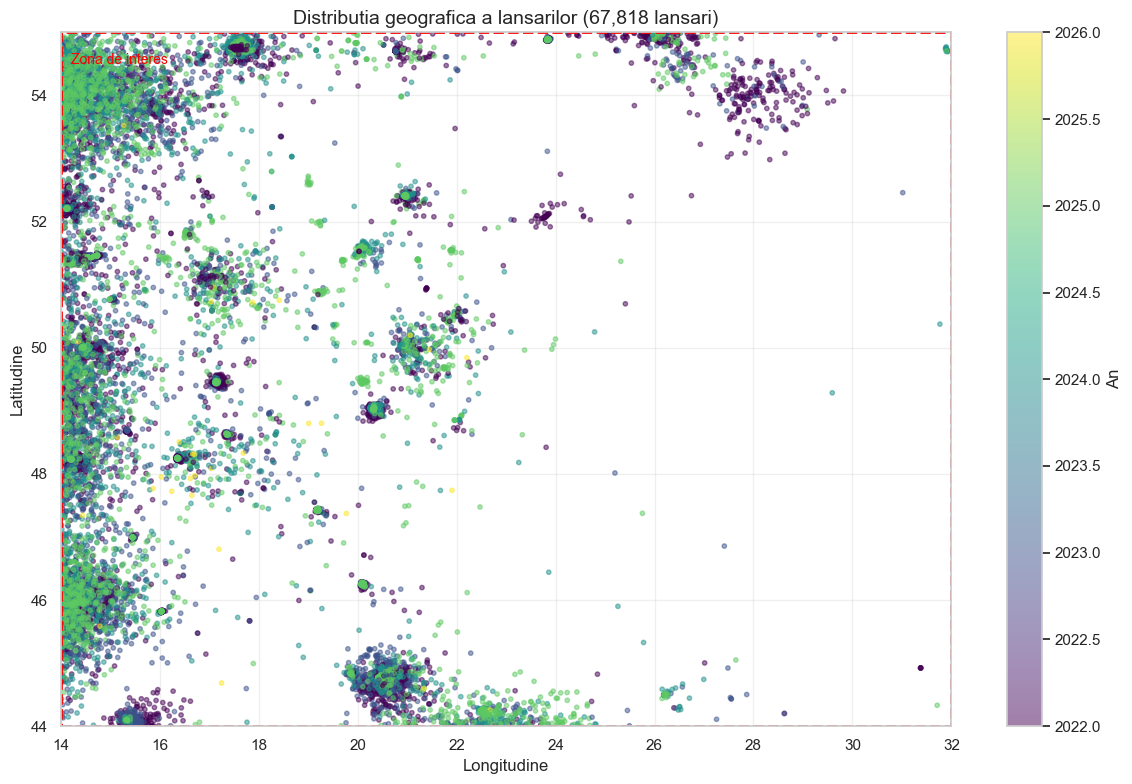

In [12]:
from matplotlib.patches import Rectangle

df_lansari = df_sh.sort_values('datetime').groupby('serial').first().reset_index()

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(
    df_lansari['lon'], df_lansari['lat'],
    c=df_lansari['year'], cmap='viridis',
    alpha=0.5, s=10
)
plt.colorbar(scatter, ax=ax, label='An')
ax.set_title(f'Distributia geografica a lansarilor ({len(df_lansari):,} lansari)', fontsize=14)
ax.set_xlabel('Longitudine')
ax.set_ylabel('Latitudine')
ax.set_xlim(14, 32)
ax.set_ylim(44, 55)
ax.grid(True, alpha=0.3)

rect = Rectangle((14, 44), 18, 11, linewidth=2, edgecolor='red', facecolor='none', linestyle='--')
ax.add_patch(rect)
ax.text(14.2, 54.5, 'Zona de interes', color='red', fontsize=10)

plt.tight_layout()
plt.savefig('harta_lansari.png', dpi=150)
plt.show()


## 5. Distribuție temporală

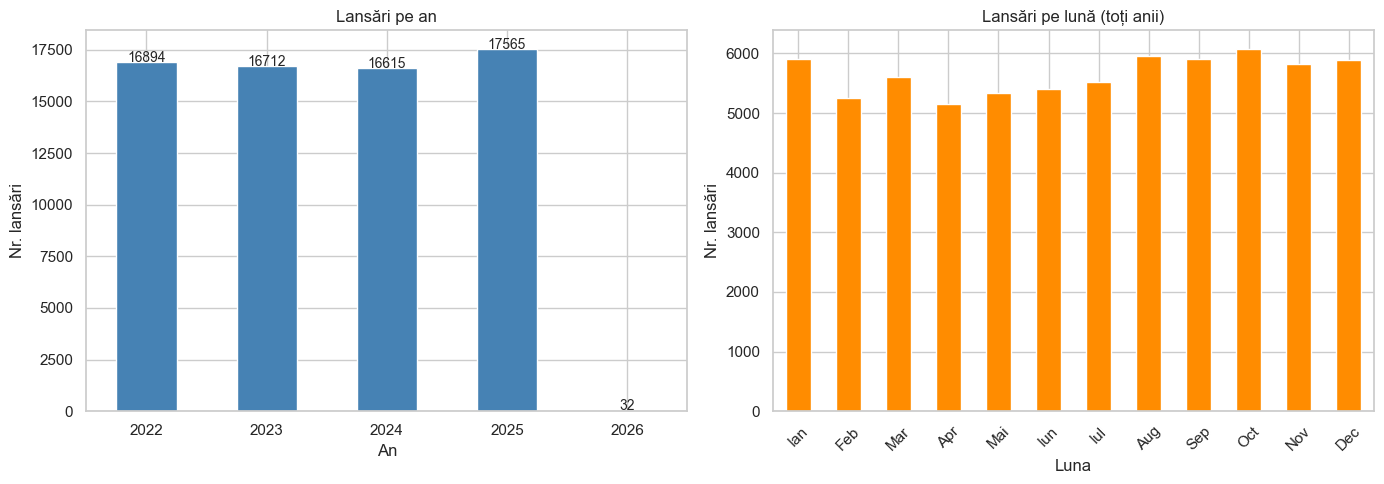

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lansari_an = df_lansari.groupby('year').size()
lansari_an.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Lansări pe an')
axes[0].set_xlabel('An')
axes[0].set_ylabel('Nr. lansări')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(lansari_an):
    axes[0].text(i, v + 2, str(v), ha='center', fontsize=10)

lansari_luna = df_lansari.groupby('month').size()
luni = ['Ian','Feb','Mar','Apr','Mai','Iun','Iul','Aug','Sep','Oct','Nov','Dec']
lansari_luna.index = [luni[i-1] for i in lansari_luna.index]
lansari_luna.plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Lansări pe lună (toți anii)')
axes[1].set_xlabel('Luna')
axes[1].set_ylabel('Nr. lansări')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('distributie_temporala.png', dpi=150)
plt.show()


## 6. Analiza altitudinii

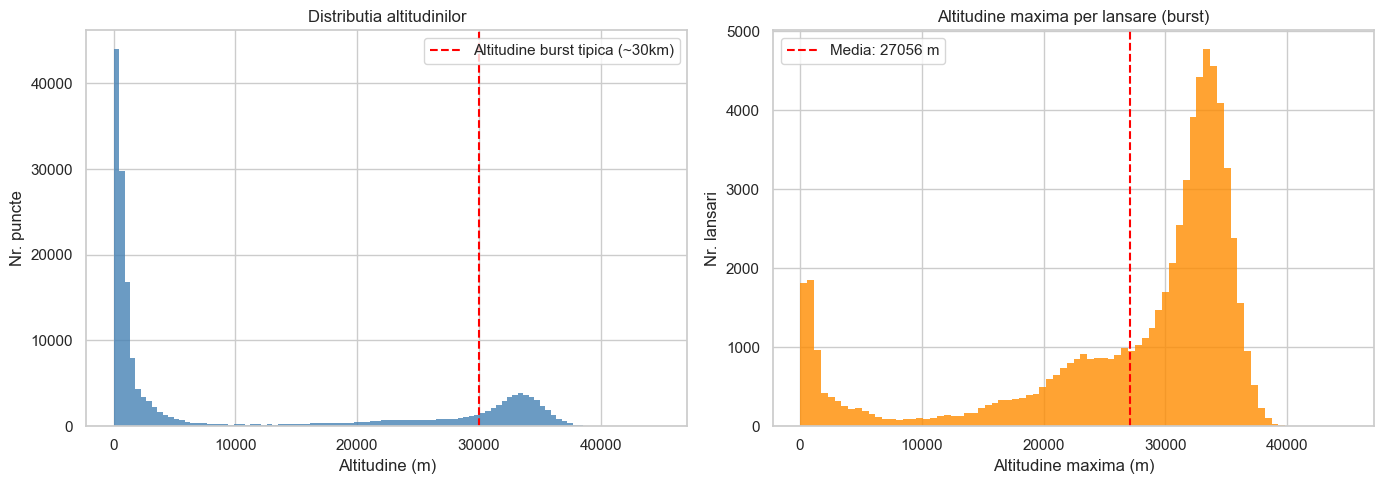

Altitudine medie maxima: 27056 m
Altitudine minima:       38 m
Altitudine maxima:       44884 m


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_sh['alt'].dropna(), bins=100, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].axvline(x=30000, color='red', linestyle='--', label='Altitudine burst tipica (~30km)')
axes[0].set_title('Distributia altitudinilor')
axes[0].set_xlabel('Altitudine (m)')
axes[0].set_ylabel('Nr. puncte')
axes[0].legend()

alt_max = df_sh.groupby('serial')['alt'].max()
axes[1].hist(alt_max, bins=80, color='darkorange', edgecolor='none', alpha=0.8)
axes[1].axvline(x=alt_max.mean(), color='red', linestyle='--', label=f'Media: {alt_max.mean():.0f} m')
axes[1].set_title('Altitudine maxima per lansare (burst)')
axes[1].set_xlabel('Altitudine maxima (m)')
axes[1].set_ylabel('Nr. lansari')
axes[1].legend()

plt.tight_layout()
plt.savefig('analiza_altitudine.png', dpi=150)
plt.show()

print(f"Altitudine medie maxima: {alt_max.mean():.0f} m")
print(f"Altitudine minima:       {alt_max.min():.0f} m")
print(f"Altitudine maxima:       {alt_max.max():.0f} m")


## 7. Temperatura și viteza vântului vs altitudine

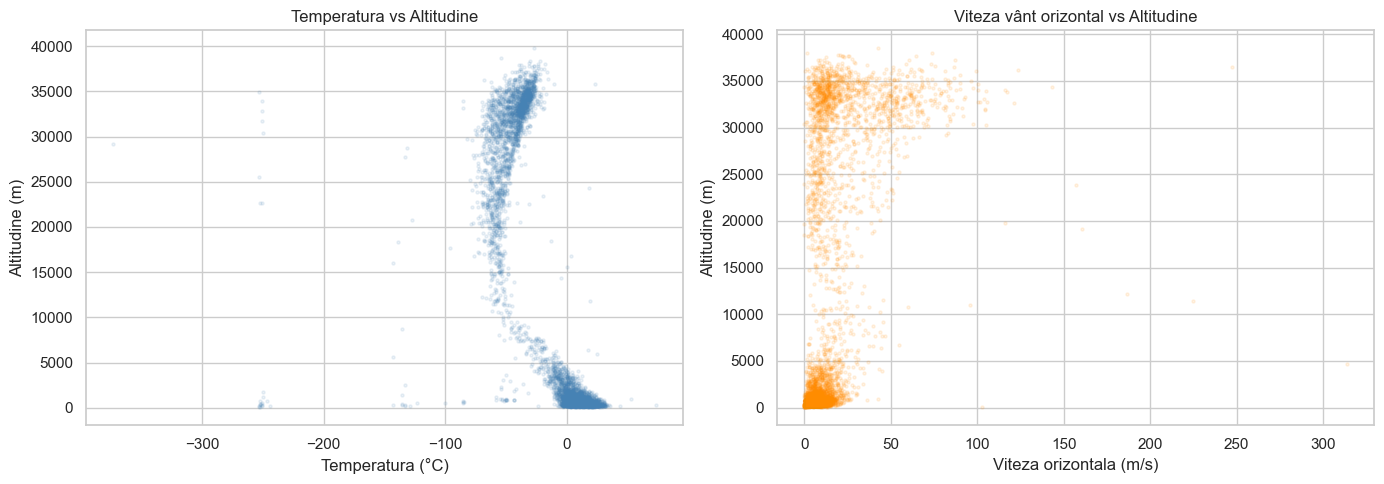

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample = df_sh[df_sh['temp'].notna()].sample(min(5000, df_sh['temp'].notna().sum()))
axes[0].scatter(sample['temp'], sample['alt'], alpha=0.1, s=5, color='steelblue')
axes[0].set_title('Temperatura vs Altitudine')
axes[0].set_xlabel('Temperatura (°C)')
axes[0].set_ylabel('Altitudine (m)')

sample2 = df_sh[df_sh['vel_h'].notna()].sample(min(5000, df_sh['vel_h'].notna().sum()))
axes[1].scatter(sample2['vel_h'], sample2['alt'], alpha=0.1, s=5, color='darkorange')
axes[1].set_title('Viteza vânt orizontal vs Altitudine')
axes[1].set_xlabel('Viteza orizontala (m/s)')
axes[1].set_ylabel('Altitudine (m)')

plt.tight_layout()
plt.savefig('temp_vant_altitudine.png', dpi=150)
plt.show()


## 8. Exemplu traiectorii complete

In [16]:
puncte_per_lansare = df_sh.groupby('serial').size().sort_values(ascending=False)
print("Top 10 lansari cu cele mai multe puncte:")
print(puncte_per_lansare.head(10))


Top 10 lansari cu cele mai multe puncte:
serial
T1841441    3
U2150977    3
U2060932    3
U2061009    3
U2061010    3
U2061011    3
U2061012    3
U2061013    3
U2061014    3
U2061040    3
dtype: int64


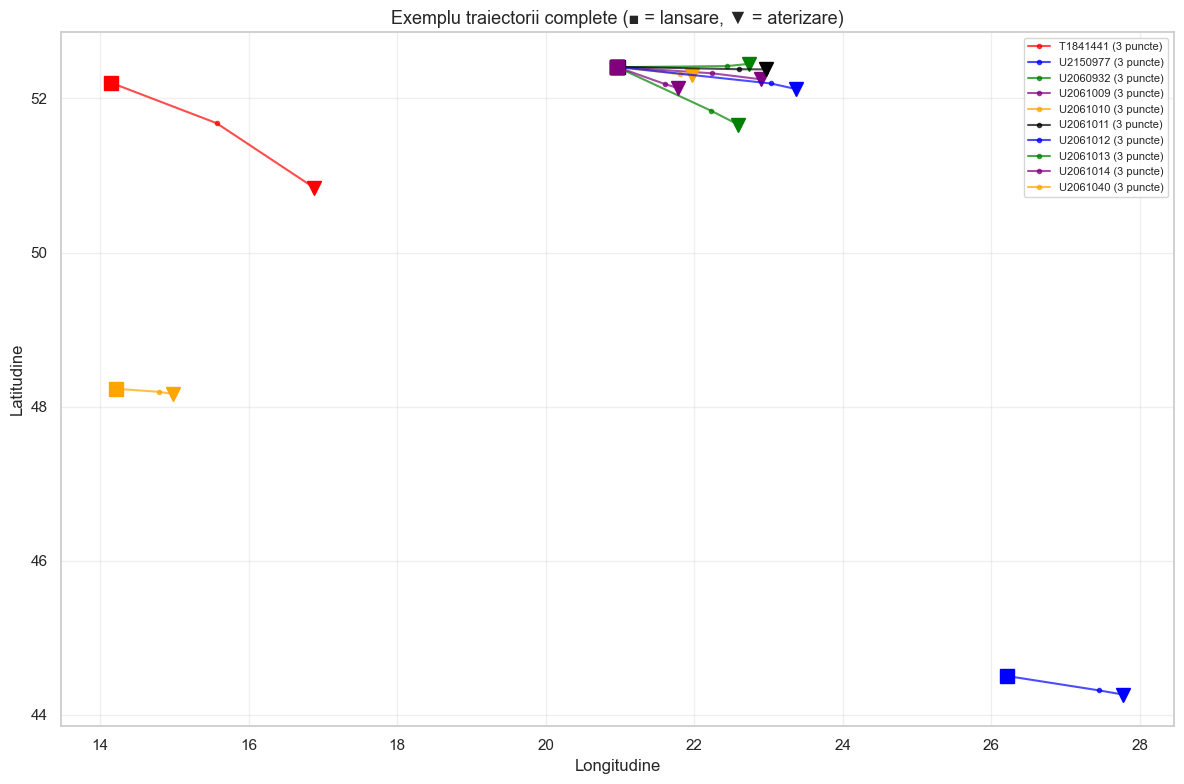

In [26]:
top_seriale = puncte_per_lansare.head(10).index
colors = ['red', 'blue', 'green', 'purple', 'orange','black','blue','green', 'purple', 'orange']

fig, ax = plt.subplots(figsize=(12, 8))
for serial, color in zip(top_seriale, colors):
    traj = df_sh[df_sh['serial'] == serial].sort_values('datetime')
    ax.plot(traj['lon'], traj['lat'], '-o', markersize=3,
            color=color, alpha=0.7, label=f'{serial} ({len(traj)} puncte)')
    ax.plot(traj['lon'].iloc[0],  traj['lat'].iloc[0],  's', color=color, markersize=10)
    ax.plot(traj['lon'].iloc[-1], traj['lat'].iloc[-1], 'v', color=color, markersize=10)

ax.set_title('Exemplu traiectorii complete (■ = lansare, ▼ = aterizare)', fontsize=13)
ax.set_xlabel('Longitudine')
ax.set_ylabel('Latitudine')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('traiectorii_exemple.png', dpi=150)
plt.show()


## 9. Analiza datelor Wyoming

In [18]:
print("=== WYOMING — Sumar ===")
print(f"Randuri totale: {len(df_wy):,}")
print(f"Statii unice: {df_wy['station_name'].nunique()}")
print(f"\nStatii disponibile:")
print(df_wy['station_name'].value_counts())


=== WYOMING — Sumar ===
Randuri totale: 1,115,667
Statii unice: 7

Statii disponibile:
station_name
Praha        231701
Budapest     229689
Poprad       227056
Bucuresti    172242
Warsaw       170533
Sofia         80552
Kiev           3894
Name: count, dtype: int64


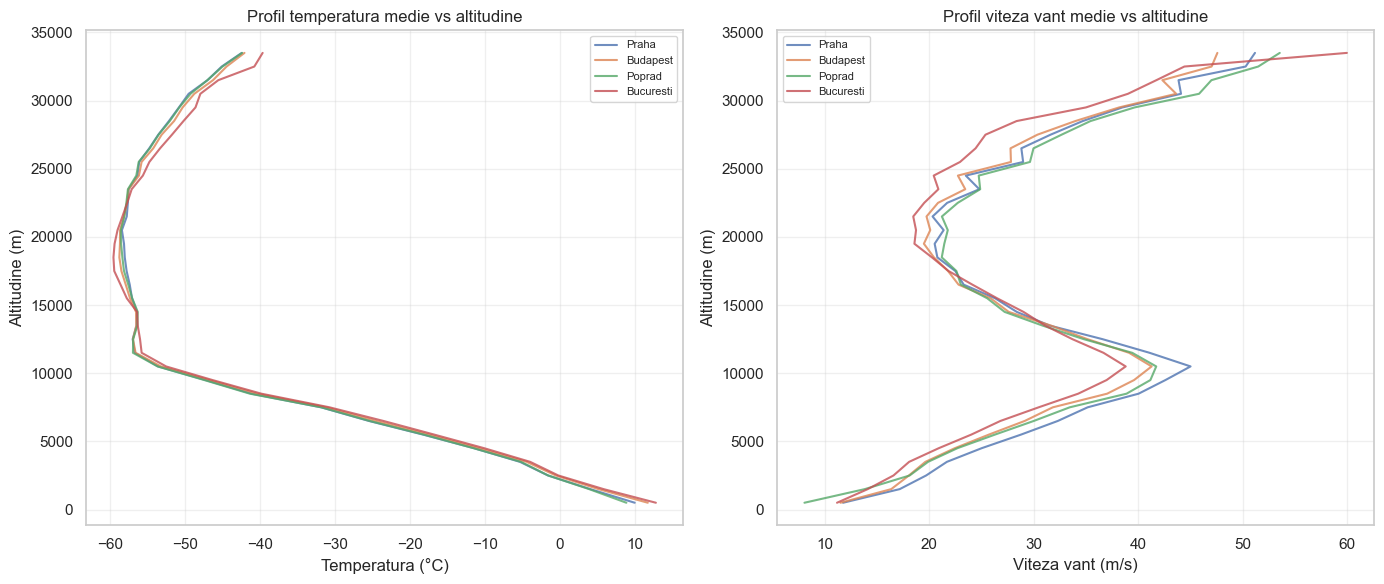

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

statii_top = df_wy['station_name'].value_counts().head(4).index

for statie in statii_top:
    subset = df_wy[df_wy['station_name'] == statie]
    profil = subset.groupby(
        pd.cut(subset['height'], bins=range(0, 35000, 1000))
    )['temperature'].mean()
    altitudini = [interval.mid for interval in profil.index]
    axes[0].plot(profil.values, altitudini, label=statie, alpha=0.8)

axes[0].set_title('Profil temperatura medie vs altitudine')
axes[0].set_xlabel('Temperatura (°C)')
axes[0].set_ylabel('Altitudine (m)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

for statie in statii_top:
    subset = df_wy[df_wy['station_name'] == statie]
    profil = subset.groupby(
        pd.cut(subset['height'], bins=range(0, 35000, 1000))
    )['speed'].mean()
    altitudini = [interval.mid for interval in profil.index]
    axes[1].plot(profil.values, altitudini, label=statie, alpha=0.8)

axes[1].set_title('Profil viteza vant medie vs altitudine')
axes[1].set_xlabel('Viteza vant (m/s)')
axes[1].set_ylabel('Altitudine (m)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('profil_atmosferic_wyoming.png', dpi=150)
plt.show()


## 10. Calculul distanței de aterizare (target ML)

In [20]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

rezultate = []
for serial, grup in df_sh.groupby('serial'):
    grup = grup.sort_values('datetime')
    if len(grup) < 3:
        continue

    primul  = grup.iloc[0]
    ultimul = grup.iloc[-1]
    alt_max = grup['alt'].max()

    dist_km = haversine(primul['lat'], primul['lon'],
                        ultimul['lat'], ultimul['lon'])

    rezultate.append({
        'serial':            serial,
        'lat_lansare':       primul['lat'],
        'lon_lansare':       primul['lon'],
        'lat_aterizare':     ultimul['lat'],
        'lon_aterizare':     ultimul['lon'],
        'alt_max_m':         alt_max,
        'dist_aterizare_km': dist_km,
        'nr_puncte':         len(grup),
        'durata_min':        (grup['datetime'].max() - grup['datetime'].min()).total_seconds() / 60,
    })

df_target = pd.DataFrame(rezultate)
print(f"Lansari cu distanta calculata: {len(df_target):,}")
print(f"\nStatistici distanta aterizare:")
print(df_target['dist_aterizare_km'].describe().round(2))


Lansari cu distanta calculata: 54,641

Statistici distanta aterizare:
count    54641.00
mean        94.20
std         71.80
min          0.00
25%         42.60
50%         75.71
75%        127.75
max        908.80
Name: dist_aterizare_km, dtype: float64


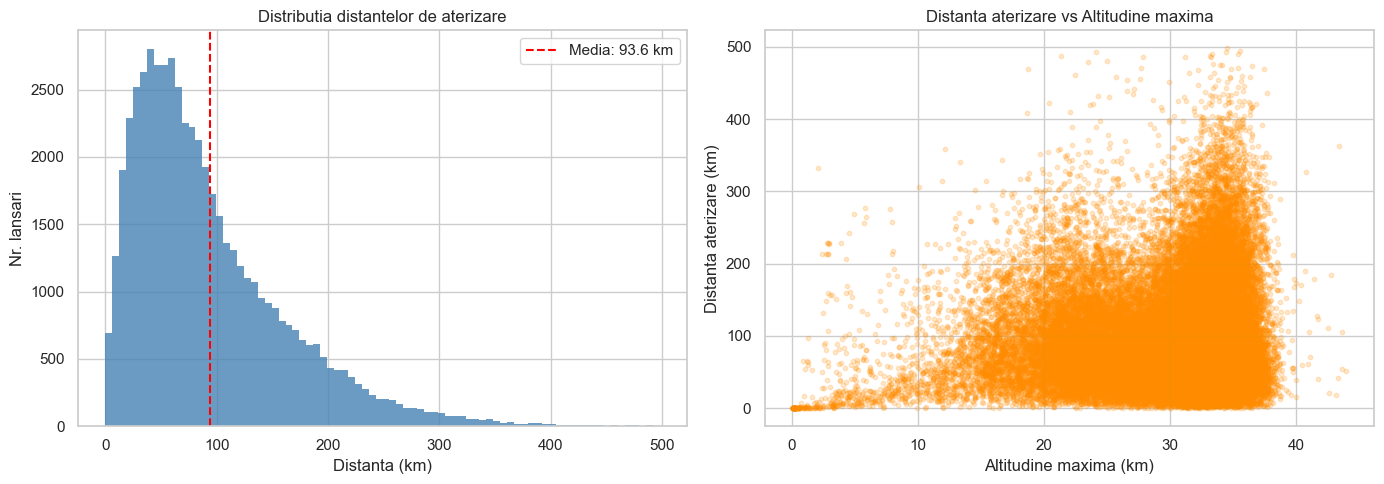

Salvat: lansari_cu_target.csv


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_plot = df_target[df_target['dist_aterizare_km'] < 500]
axes[0].hist(df_plot['dist_aterizare_km'], bins=80, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].axvline(df_plot['dist_aterizare_km'].mean(), color='red', linestyle='--',
                label=f"Media: {df_plot['dist_aterizare_km'].mean():.1f} km")
axes[0].set_title('Distributia distantelor de aterizare')
axes[0].set_xlabel('Distanta (km)')
axes[0].set_ylabel('Nr. lansari')
axes[0].legend()

axes[1].scatter(df_plot['alt_max_m']/1000, df_plot['dist_aterizare_km'],
                alpha=0.2, s=10, color='darkorange')
axes[1].set_title('Distanta aterizare vs Altitudine maxima')
axes[1].set_xlabel('Altitudine maxima (km)')
axes[1].set_ylabel('Distanta aterizare (km)')

plt.tight_layout()
plt.savefig('distanta_aterizare.png', dpi=150)
plt.show()

df_target.to_csv(r"D:\User\Documents\GitHub\ML---proiect\Date\lansari_cu_target.csv", index=False)
print("Salvat: lansari_cu_target.csv")


## 11. Corelații între variabile

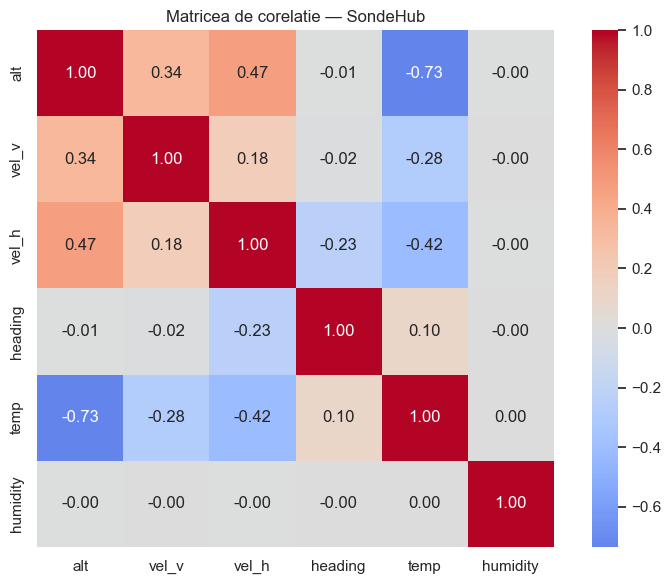

In [22]:
cols_corr = ['alt', 'vel_v', 'vel_h', 'heading', 'temp', 'humidity']
df_corr = df_sh[cols_corr].dropna()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True)
ax.set_title('Matricea de corelatie — SondeHub')
plt.tight_layout()
plt.savefig('corelatie_sondehub.png', dpi=150)
plt.show()
